<a href="https://colab.research.google.com/github/dashakudjaeva/HW/blob/hw_1/hw_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Постановка задачи и описание датасета**

**Бизнес-постановка**

Компания сталкивается с проблемой высокой текучести кадров (Attrition). Уход ценных сотрудников приводит к дополнительным расходам на подбор, адаптацию и потере производительности. Задача — заранее выявлять сотрудников, склонных к увольнению, чтобы предложить им меры удержания (повышение зарплаты, изменение графика, обучение и т.п.).

**ML-постановка**

Задача относится к бинарной классификации. Целевая переменная Attrition принимает два значения:

Yes – сотрудник уволился,
No – сотрудник остался.


**Описание набора данных**

Датасет содержит информацию о сотрудниках компании. Всего 1470 записей и 35 признаков (включая целевую переменную). Описание основных колонок:

* Age – возраст,
* Attrition – целевая переменная,
* BusinessTravel – частота командировок,
* DailyRate – дневная ставка,
* Department – отдел,
* DistanceFromHome – расстояние от дома до работы,
* Education – уровень образования,
* EducationField – область образования,
EmployeeCount – количество сотрудников (всегда 1, бесполезно),
* EmployeeNumber – идентификатор сотрудника (неинформативен),
* EnvironmentSatisfaction – удовлетворённость окружением,
* Gender – пол,
* HourlyRate – почасовая ставка,
* JobInvolvement – вовлечённость в работу,
* JobLevel – уровень должности,
* JobRole – роль,
* JobSatisfaction – удовлетворённость работой,
* MaritalStatus – семейное положение,
* MonthlyIncome – месячный доход,
* MonthlyRate – месячная ставка,
* NumCompaniesWorked – количество компаний, в которых работал,
* Over18 – возраст > 18 (всегда Y, бесполезно),
* OverTime – переработки,
* PercentSalaryHike – процент повышения зарплаты,
* PerformanceRating – оценка эффективности,
* RelationshipSatisfaction – удовлетворённость отношениями,
* StandardHours – стандартные часы (всегда 80, бесполезно),
* StockOptionLevel – уровень опционов,
* TotalWorkingYears – общий стаж,
* TrainingTimesLastYear – количество тренингов за последний год,
* WorkLifeBalance – баланс работы и личной жизни,
* YearsAtCompany – стаж в компании,
* YearsInCurrentRole – стаж в текущей роли,
* YearsSinceLastPromotion – лет с последнего повышения,
* YearsWithCurrManager – лет с текущим руководителем.

# **2. Выбор метрики оценки качества**

Классы в данных несбалансированы (около 84% сотрудников остаются, 16% уходят).
Accuracy может быть обманчивой. Бизнес-цель – минимизировать как ложные срабатывания (предложение удержания тому, кто и так остался), так и ложные пропуски (упустить потенциального уходящего). Однако удержание ценного сотрудника часто важнее, поэтому основной акцент стоит сделать на полноте (recall) для класса увольнения.

Оптимальная метрика – F1‑мера (среднее гармоническое точности и полноты) для класса Attrition = Yes.
Дополнительно будем отслеживать ROC‑AUC, который даёт интегральную оценку разделяющей способности.

Обоснование: F1‑score сбалансирует точность и полноту, что важно при дисбалансе классов. ROC‑AUC полезна для сравнения моделей, но менее интерпретируема для бизнеса.

# **3. Разведочный анализ данных (EDA)**

**3.1 Импорт библиотек и загрузка данных**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**3.2 Общая информация и обработка пропусков**

In [2]:
df.info()
df.describe()

# Проверим пропуски
print(df.isnull().sum().sort_values(ascending=False))

# Создадим бинарную целевую переменную
df['Attrition_binary'] = (df['Attrition'] == 'Yes').astype(int)

# Удалим неинформативные столбцы
df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**3.3 Распределение целевой переменной**

Attrition
No     1233
Yes     237
Name: count, dtype: int64


/tmp/ipykernel_170/2073010914.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette='Set2')


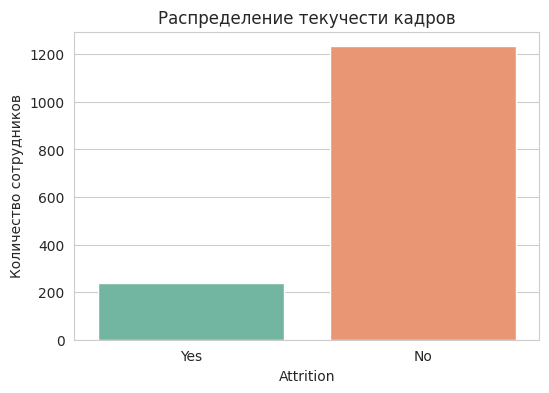

In [3]:
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Attrition', palette='Set2')
plt.title('Распределение текучести кадров')
plt.ylabel('Количество сотрудников')
plt.show()

# Интерактивная круговая диаграмма
fig = px.pie(df, names='Attrition', title='Доля уволившихся сотрудников', hole=0.3)
fig.show()

Вывод: Классы несбалансированы: 1233 остались (83.9%) и 237 ушли (16.1%). Это подтверждает необходимость использования F1-меры и методов борьбы с дисбалансом.

**3.4 Анализ категориальных признаков**

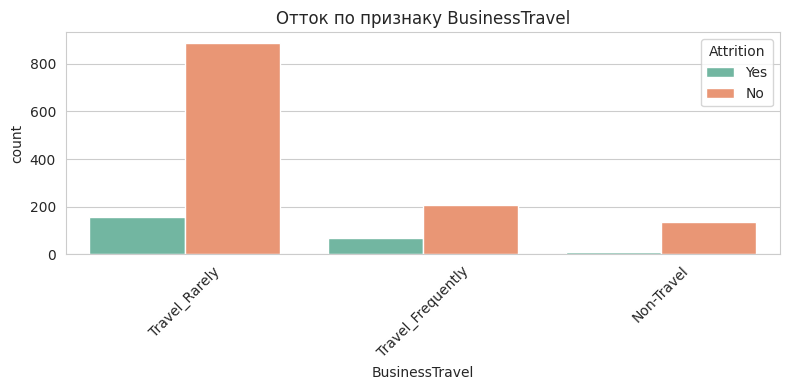

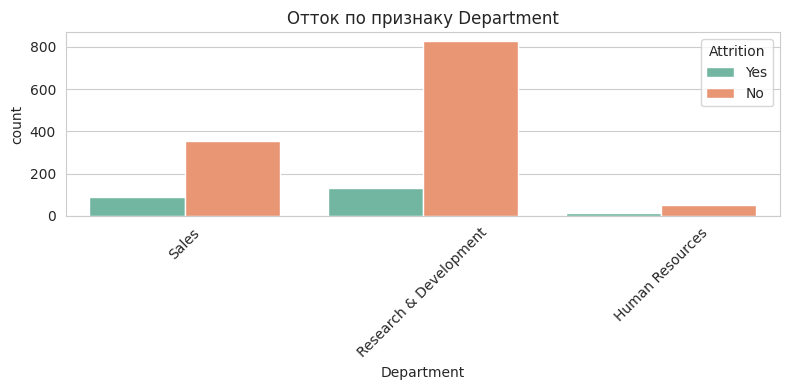

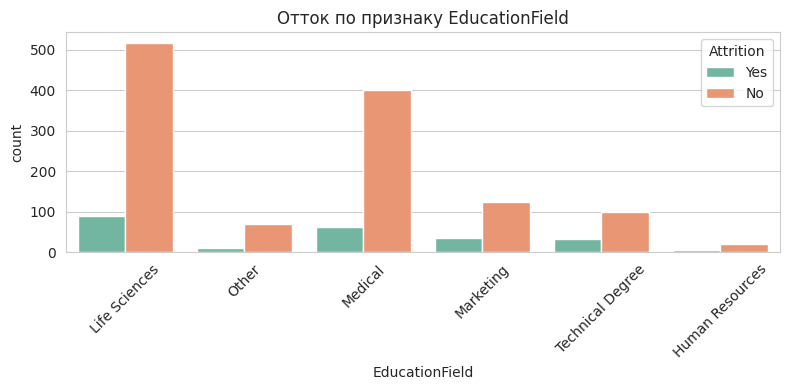

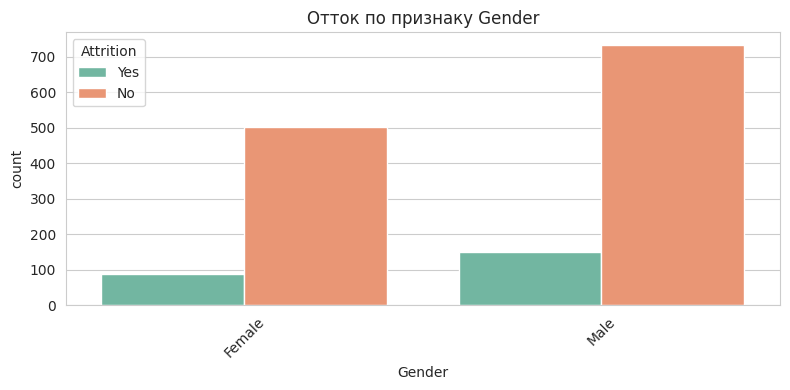

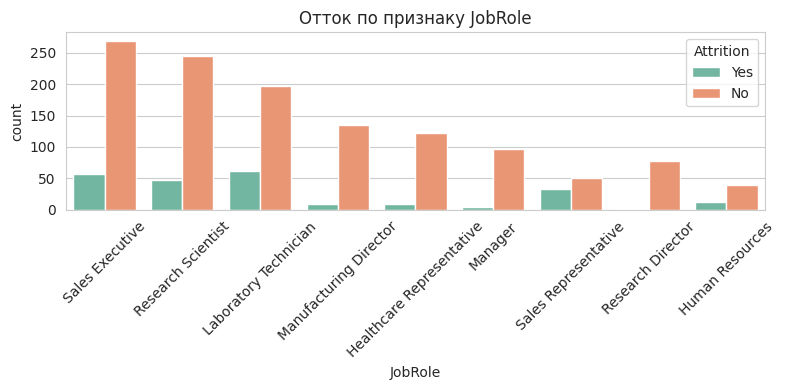

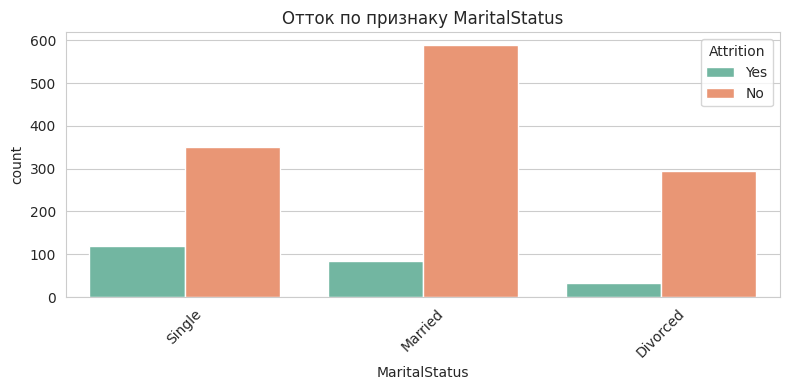

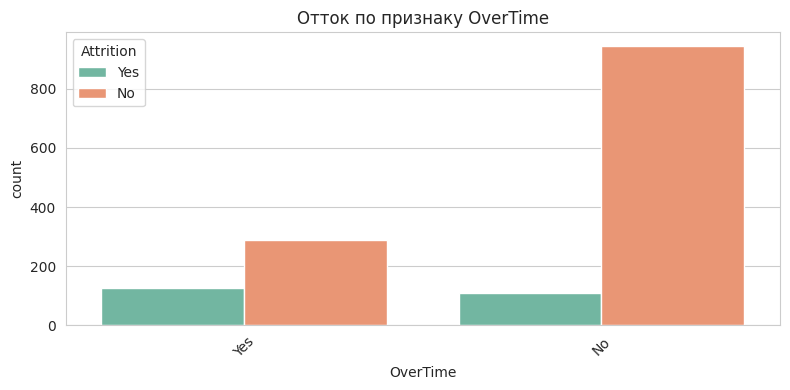

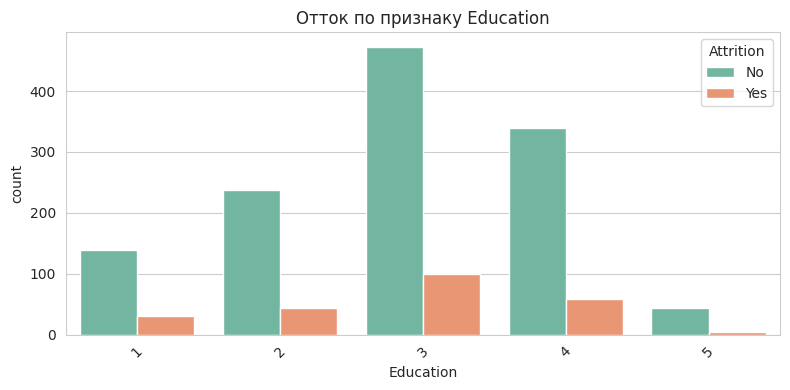

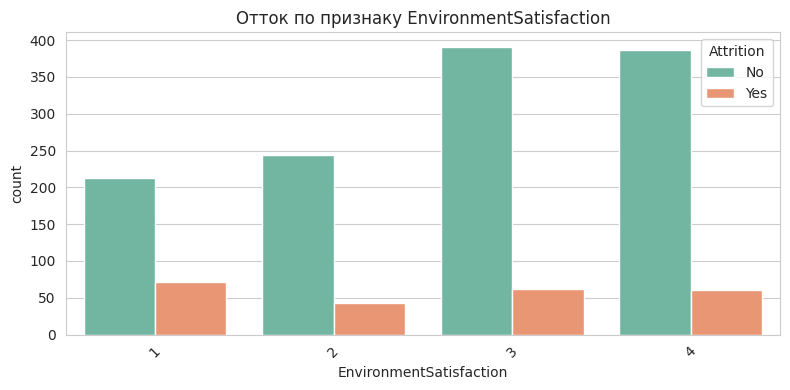

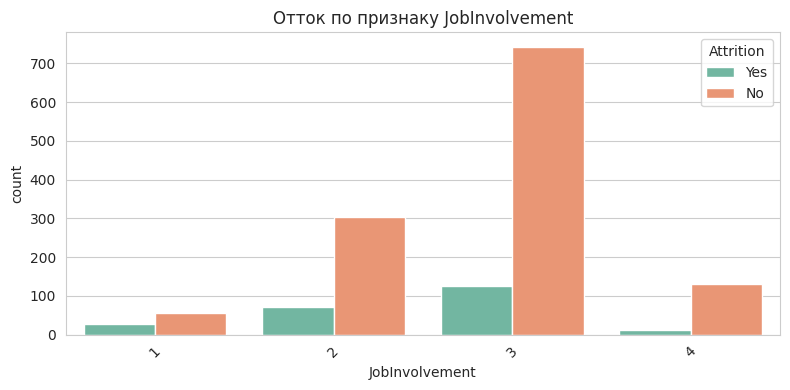

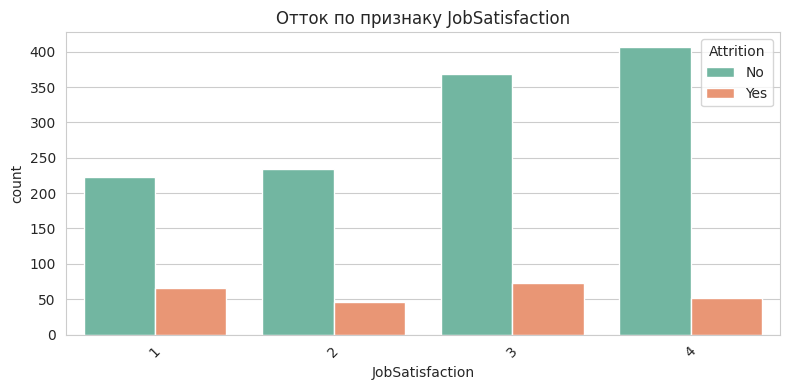

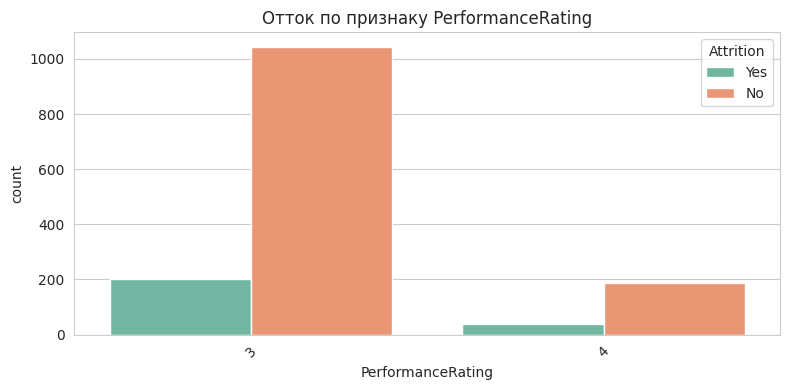

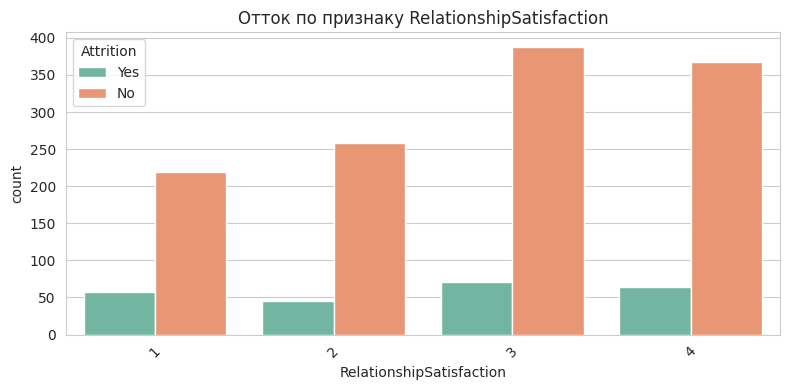

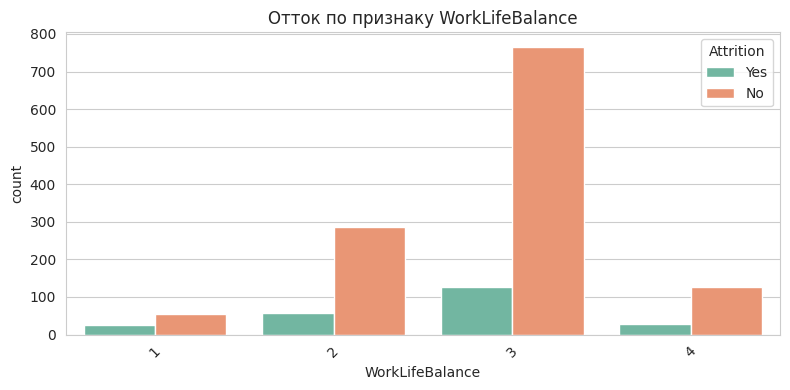

In [4]:
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
            'MaritalStatus', 'OverTime', 'Education', 'EnvironmentSatisfaction',
            'JobInvolvement', 'JobSatisfaction', 'PerformanceRating',
            'RelationshipSatisfaction', 'WorkLifeBalance']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='Attrition', palette='Set2')
    plt.title(f'Отток по признаку {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Интерпретация:

* OverTime: сотрудники, работающие сверхурочно, уходят значительно чаще.
* BusinessTravel: частые командировки (Travel_Frequently) связаны с повышенным оттоком.
* Department: в отделе Sales отток выше, чем в R&D и HR.
* JobRole: Sales Representatives и Sales Executives имеют высокий отток.
* MaritalStatus: разведённые (Divorced) и одинокие (Single) уходят чаще, чем женатые/замужние.
* EducationField: значительных различий не наблюдается, но Life Sciences и Medical чуть выше.
* Удовлетворённость (EnvironmentSatisfaction, JobSatisfaction, RelationshipSatisfaction): чем ниже удовлетворённость, тем выше отток.
* WorkLifeBalance: низкий баланс (1) ассоциируется с оттоком.

**3.5 Анализ числовых признаков**

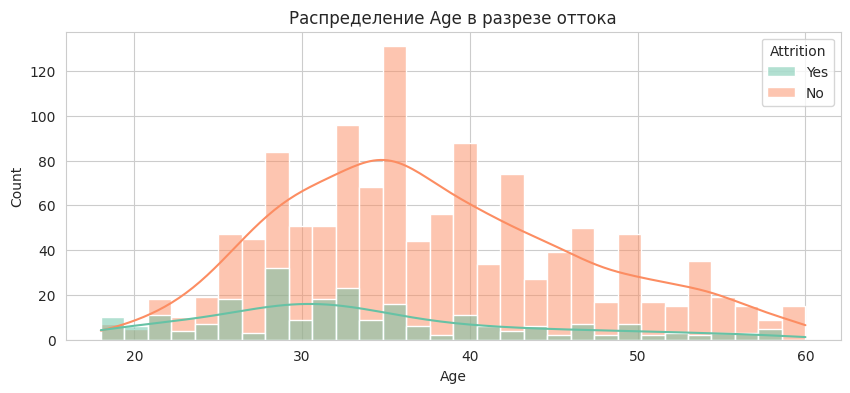

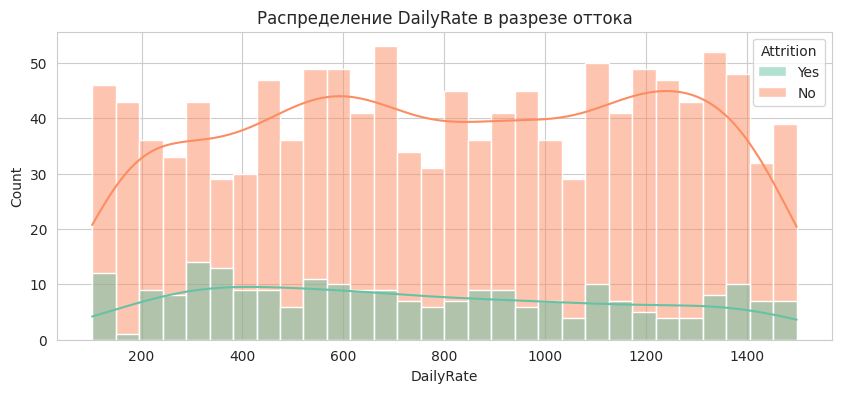

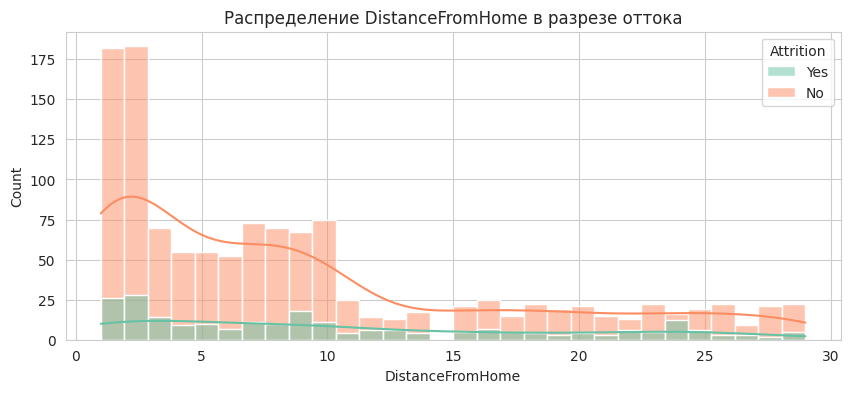

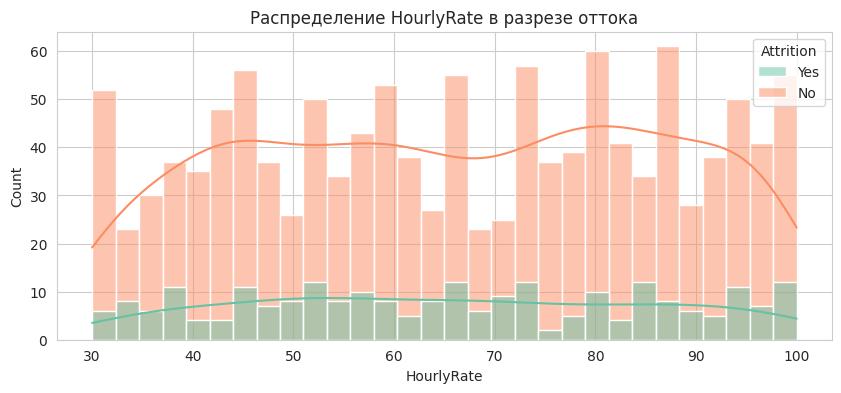

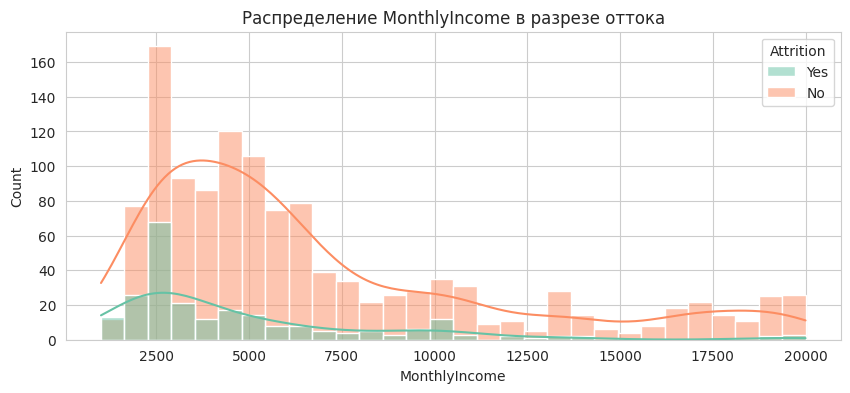

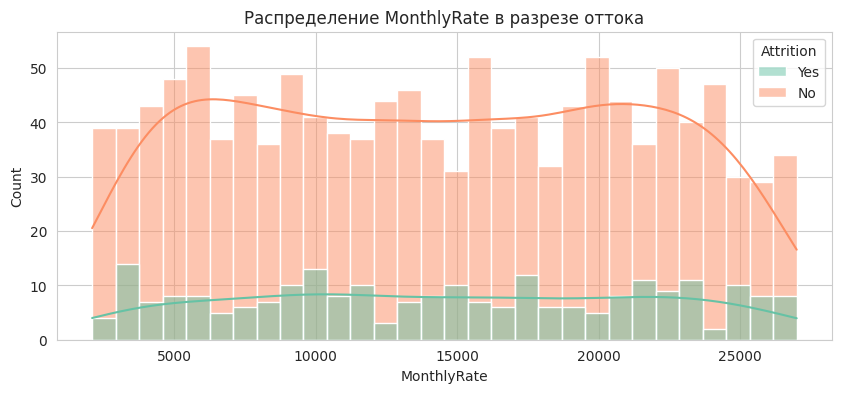

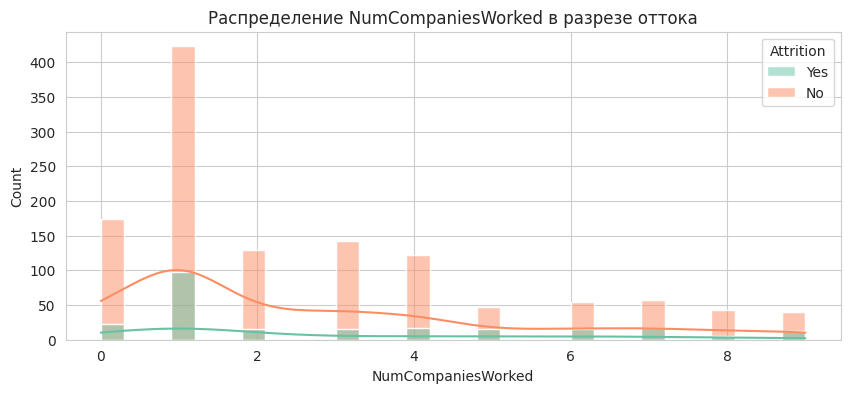

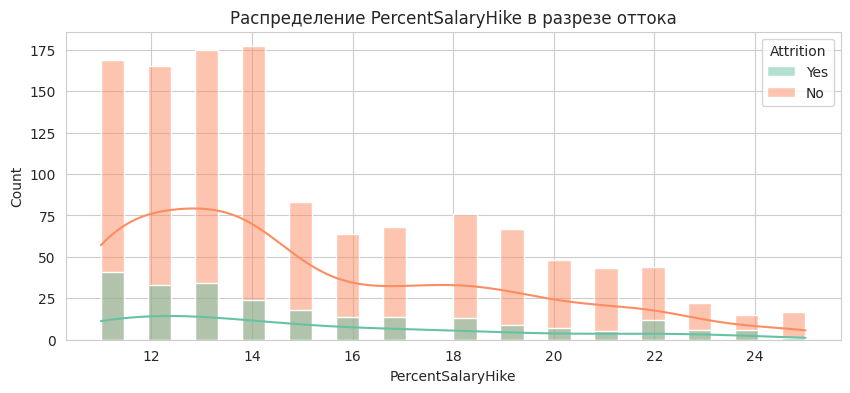

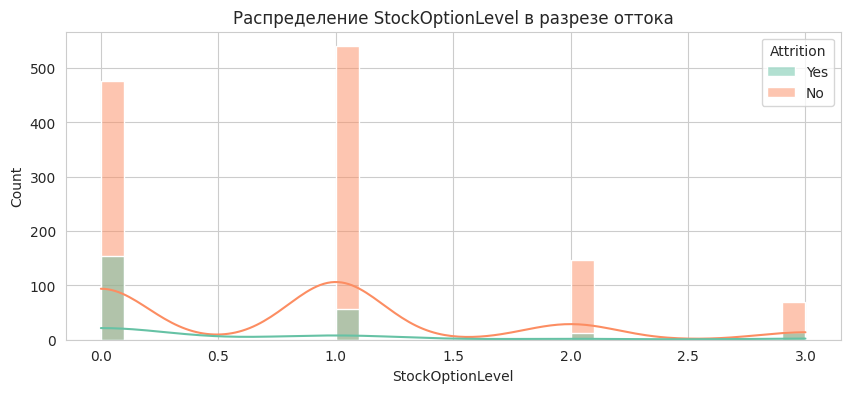

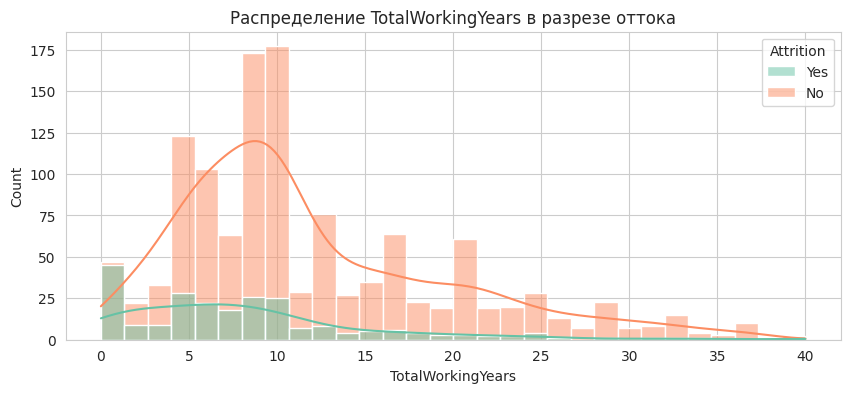

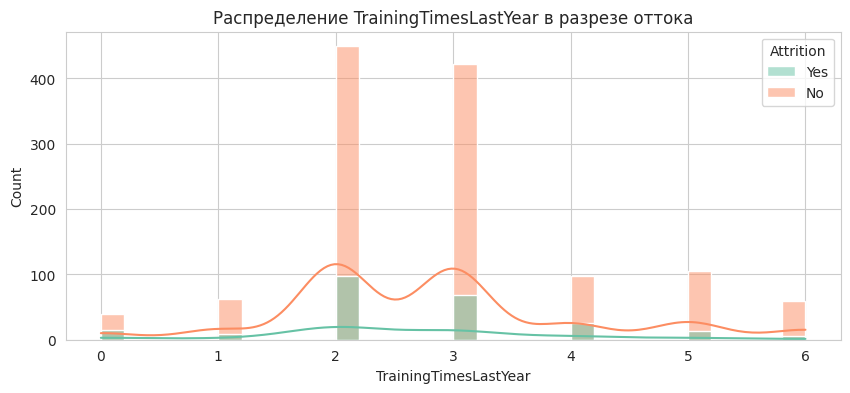

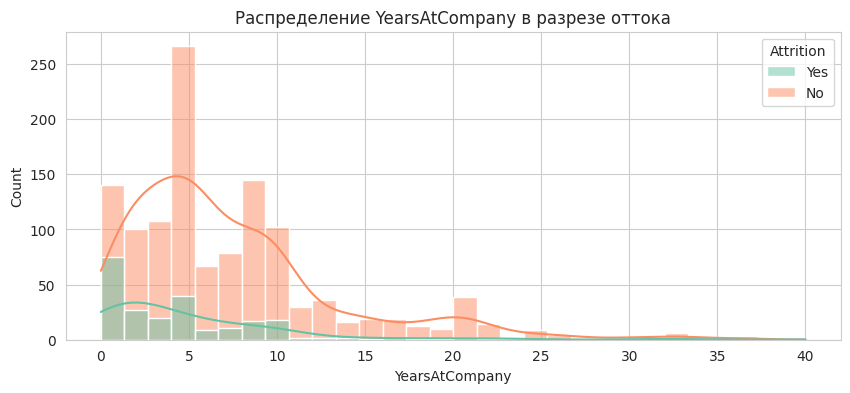

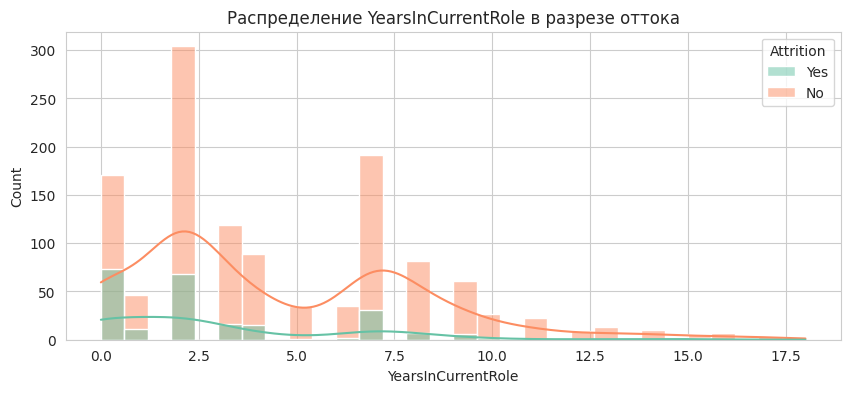

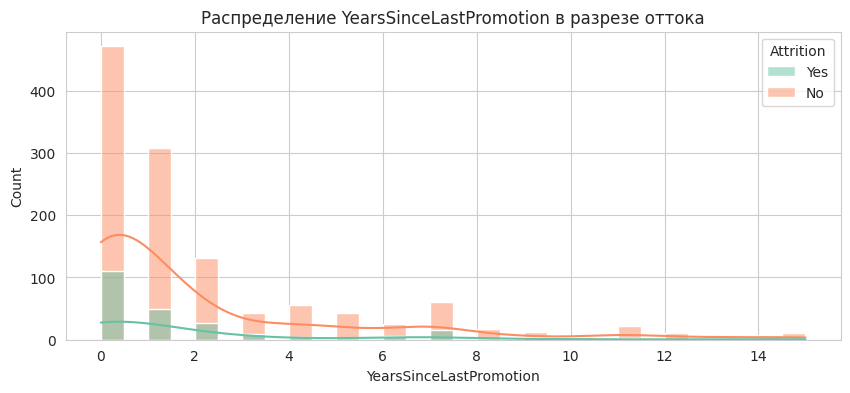

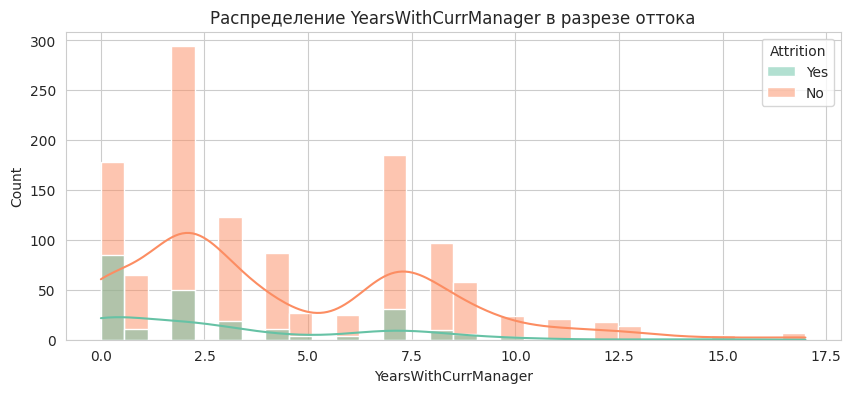

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




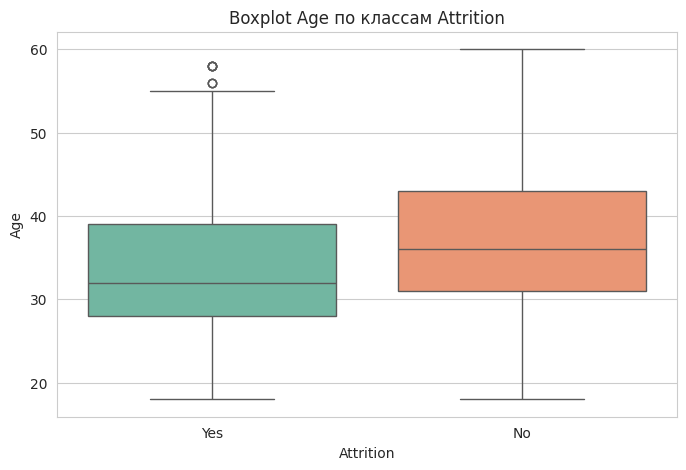

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




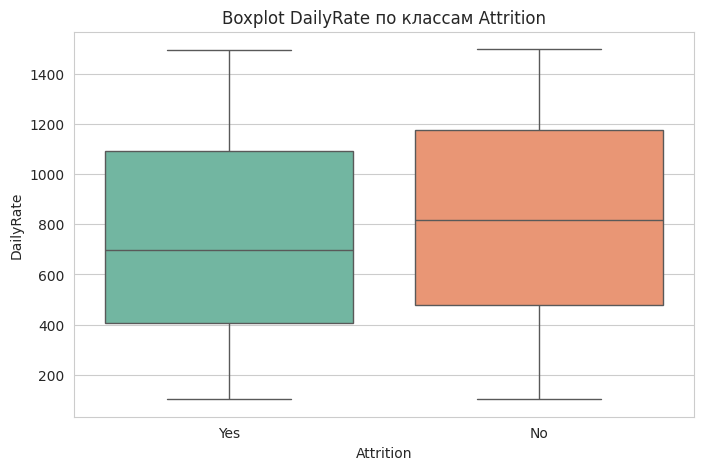

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




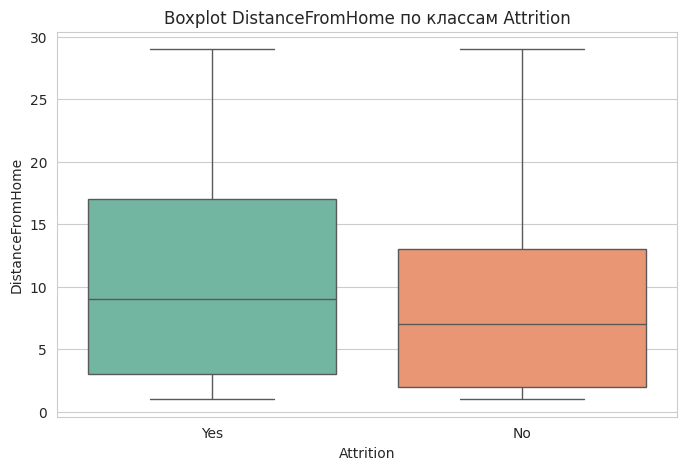

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




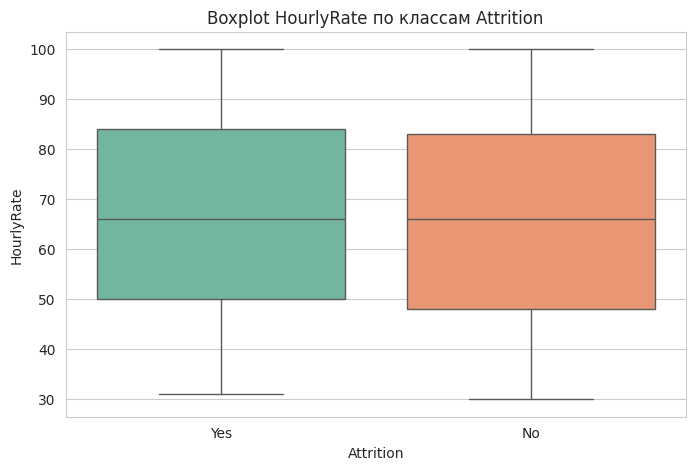

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




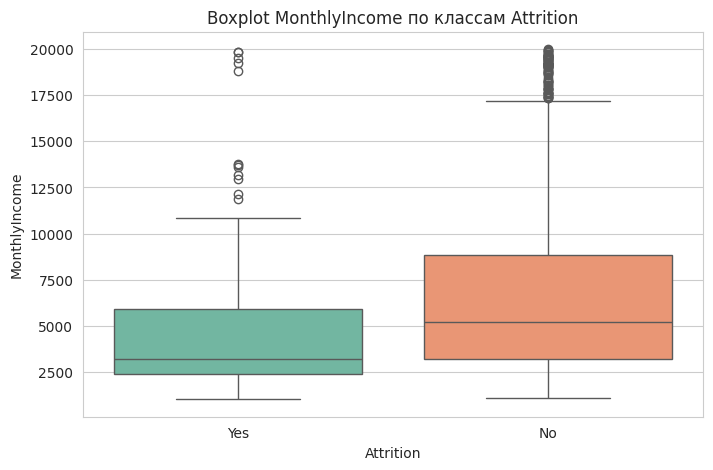

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




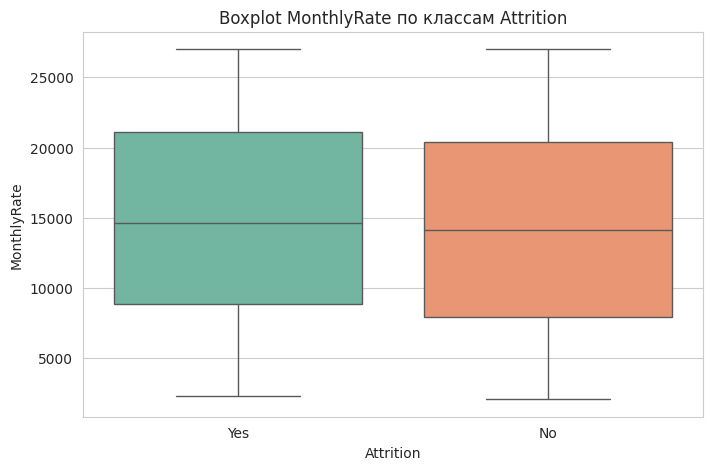

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




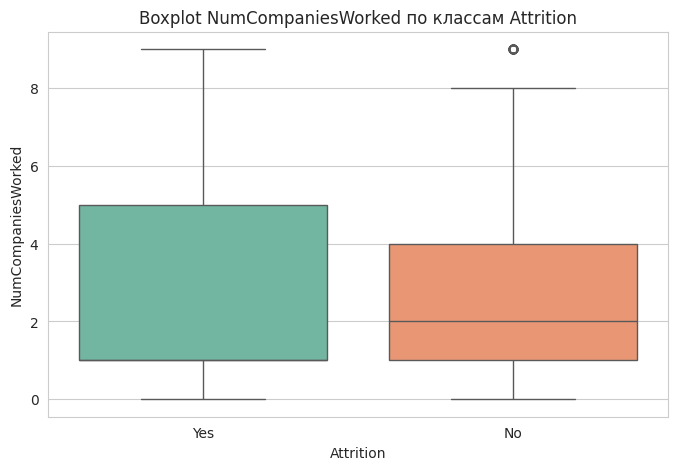

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




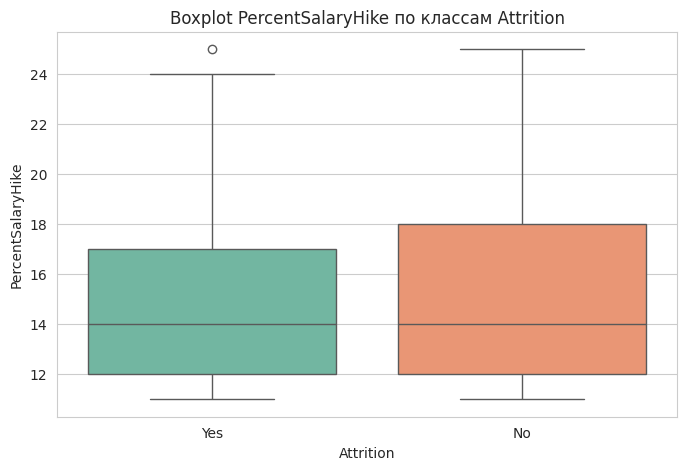

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




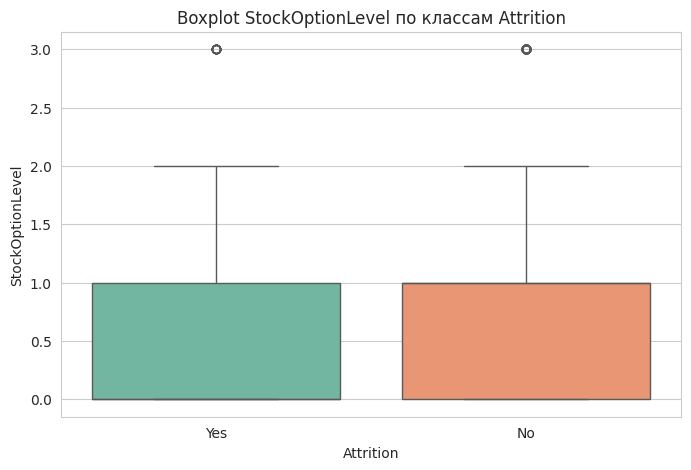

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




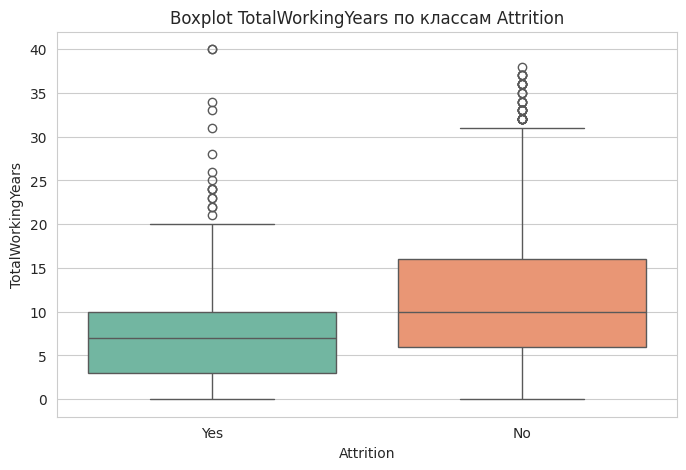

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




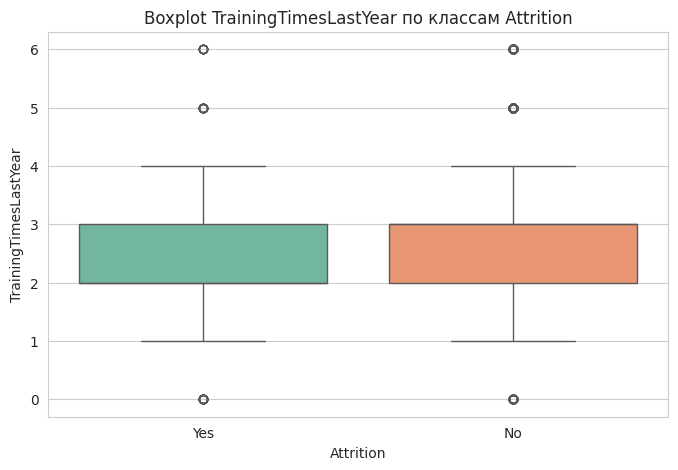

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




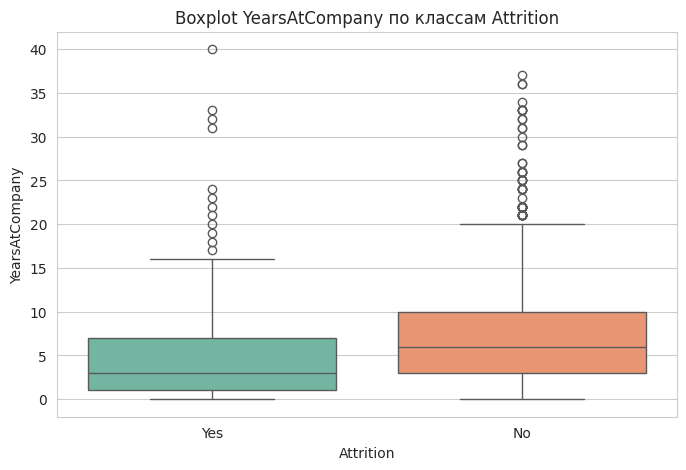

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




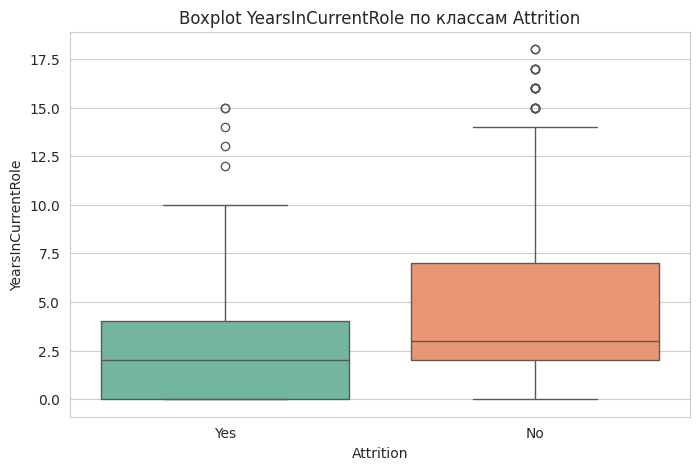

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




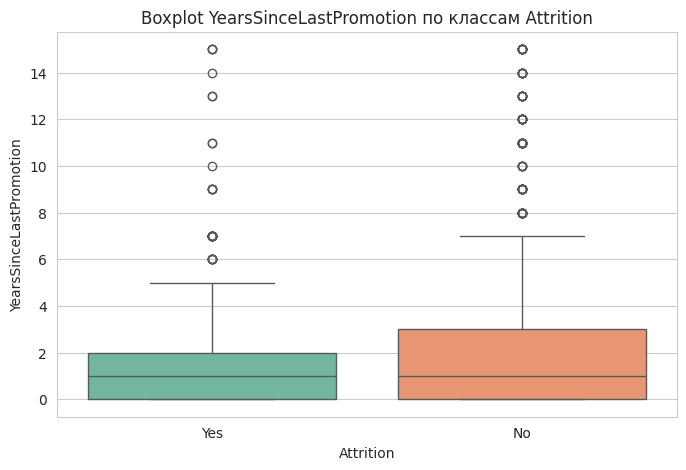

/tmp/ipykernel_170/437750994.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




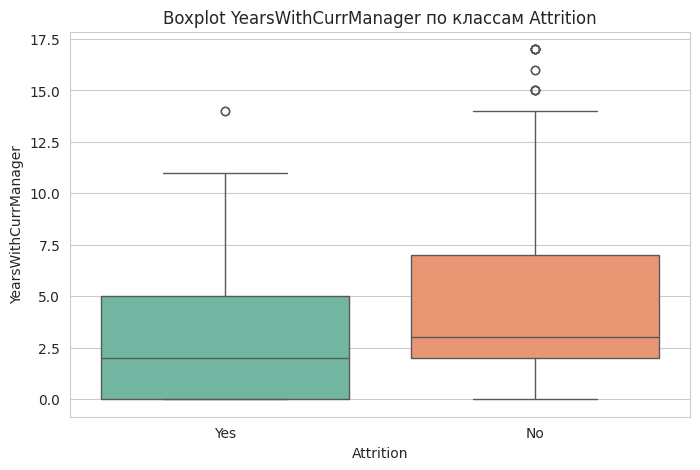

In [5]:
num_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
            'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel',
            'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
            'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

for col in num_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(data=df, x=col, hue='Attrition', kde=True, bins=30, palette='Set2')
    plt.title(f'Распределение {col} в разрезе оттока')
    plt.show()

# Ящики с усами
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x='Attrition', y=col, palette='Set2')
    plt.title(f'Boxplot {col} по классам Attrition')
    plt.show()

Интерпретация:

* Age: уволившиеся сотрудники в среднем моложе.
* DistanceFromHome: большая удалённость от дома (более 10 км) коррелирует с оттоком.
* MonthlyIncome: уволившиеся имеют в среднем меньший доход.
* NumCompaniesWorked: те, кто часто менял компании, чаще уходят.
* YearsAtCompany, YearsInCurrentRole,YearsSinceLastPromotion, YearsWithCurrManager: низкие значения этих показателей связаны с оттоком.
* TrainingTimesLastYear: меньше тренингов – выше риск увольнения.
* PercentSalaryHike: незначительная разница.
* StockOptionLevel: низкий уровень опционов – выше отток.
* DailyRate, HourlyRate, MonthlyRate: видимых закономерностей не видно.

**3.6 Корреляционный анализ**

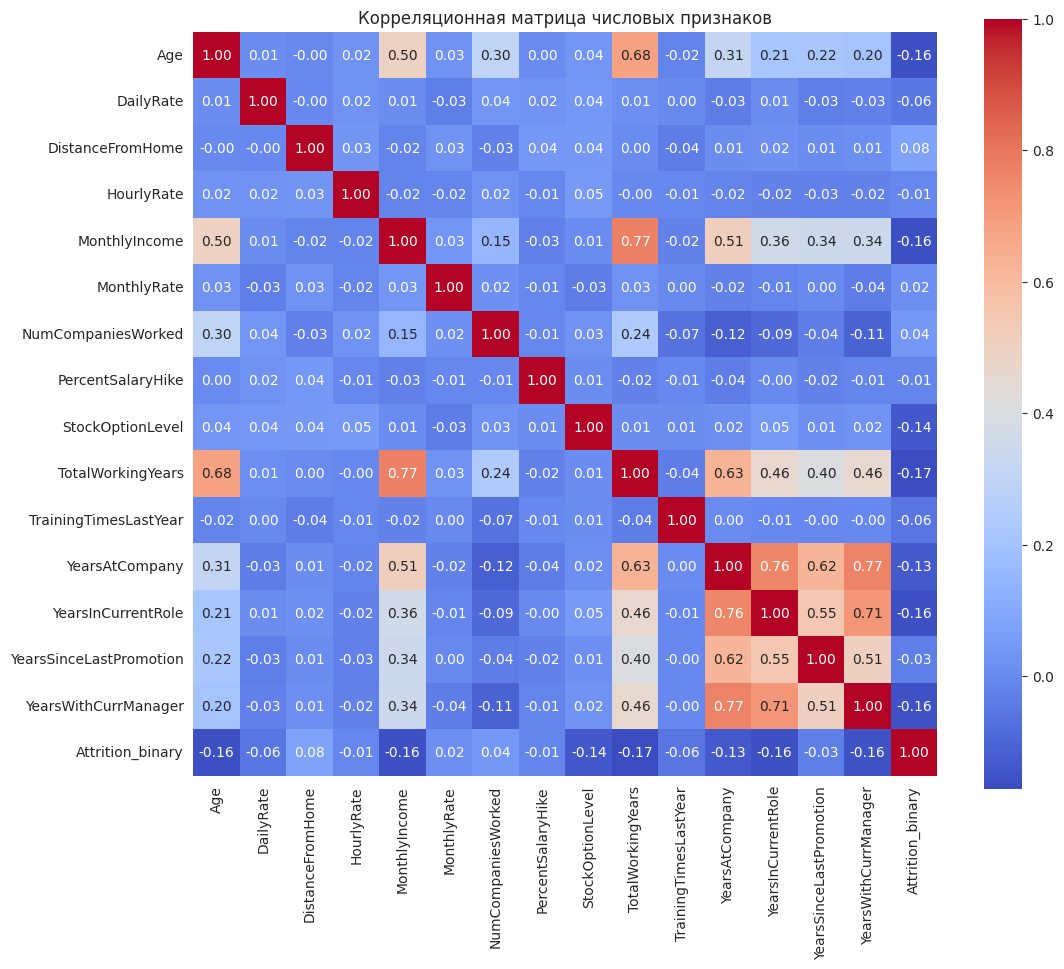

In [6]:
num_features = df[num_cols + ['Attrition_binary']]
corr = num_features.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

Выводы по корреляции:

* Attrition_binary отрицательно коррелирует с YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager, Age, MonthlyIncome, TotalWorkingYears. Чем дольше сотрудник работает, тем меньше вероятность ухода.
Положительная корреляция с NumCompaniesWorked (частые смены работы) и OverTime (переработки).
* Мультиколлинеарность: YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager сильно коррелируют между собой. Возможно, потребуется отбор признаков или регуляризация для линейных моделей.

**3.7 Интерактивные визуализации (plotly)**

In [7]:
# Scatter plot: MonthlyIncome vs Age
fig = px.scatter(df, x='Age', y='MonthlyIncome', color='Attrition',
                 hover_data=['JobRole', 'Department'],
                 title='Отток в зависимости от возраста и дохода')
fig.show()

# Bar plot: отток по OverTime и JobRole
agg_df = df.groupby(['OverTime', 'JobRole'])['Attrition_binary'].mean().reset_index()
fig = px.bar(agg_df, x='JobRole', y='Attrition_binary', color='OverTime',
             barmode='group', title='Доля оттока в зависимости от переработок и должности')
fig.show()

Интерпретация:

* На scatter plot видно, что уволившиеся сотрудники часто имеют меньший доход и, возможно, моложе.
* Переработки (OverTime) сильно увеличивают отток, особенно для ролей Sales Representative и Sales Executive.


**3.8 Анализ взаимодействия признаков**

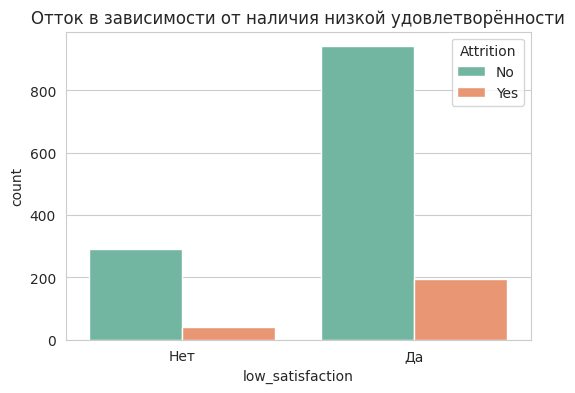

In [8]:
# Создадим признак: низкая удовлетворённость (ниже 2 по любой из шкал)
df['low_satisfaction'] = ((df['EnvironmentSatisfaction'] <= 2) |
                          (df['JobSatisfaction'] <= 2) |
                          (df['RelationshipSatisfaction'] <= 2)).astype(int)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='low_satisfaction', hue='Attrition', palette='Set2')
plt.title('Отток в зависимости от наличия низкой удовлетворённости')
plt.xticks([0,1], ['Нет', 'Да'])
plt.show()

Низкая удовлетворённость (хотя бы по одному параметру) сильно коррелирует с оттоком. Этот признак может быть полезен для модели.

# **4. Выводы по EDA**

Ключевые факторы оттока:
* Переработки (OverTime)
* Частые командировки (BusinessTravel)
* Низкая удовлетворённость (EnvironmentSatisfaction, JobSatisfaction, RelationshipSatisfaction)
* Низкий стаж в компании (YearsAtCompany, YearsInCurrentRole)
* Малый возраст
* Частая смена работы (NumCompaniesWorked)
* Низкий доход (MonthlyIncome)
* Дисбаланс классов (16% ухода) требует использования метрик F1 и ROC-AUC, а также методов балансировки (например, взвешивание классов или SMOTE).

Необходимая предобработка:
* Удалить неинформативные столбцы (EmployeeCount, Over18, StandardHours, EmployeeNumber).
* Закодировать категориальные признаки (One-Hot Encoding).
* Масштабировать числовые признаки (StandardScaler).
* Возможно, создать комбинированные признаки (например, low_satisfaction).

Возможные проблемы:
* Мультиколлинеарность между признаками стажа и дохода.
* Высокая размерность после one-hot encoding.
* Наличие выбросов в числовых признаках (необходимо проверить и обработать).

Для моделирования необходимо:
* Использовать стратифицированную кросс-валидацию.
* Провести отбор признаков для улучшения интерпретируемости и снижения переобучения.